# Where should a sporting body build a generation of fans?

Brisbane hosts the 2032 Olympic and Paralympic Games. This analysis asks where an
Australian sporting body should concentrate effort to grow youth participation, using
AusPlay national participation data and articles collected through the Guardian API.

**Headline finding:** around 84% of estimated 5–14 participation sits inside the top 20
sports, so spreading investment evenly across 142 would put most of the money where
almost none of the young people are.

See the repository README for data sources, method, limitations and how to run this.


---
## Scenario for analysis 1 and analysis 2 (Part A)

You are working as a Data Scientist assisting the [Australian Sports Commission](https://www.ausport.gov.au) (ASC) in the lead-up to the [Brisbane 2032 Olympic Games](https://www.olympics.com/en/brisbane-2032/).

A recommendation needing investigation is for the ASC to build fan support for athletes over the next 6 years through strategically connecting with school age children and youth.

Your task is to investigage how relevant data might inform this strategy, particularly by taking advantage of the following suggestions:

1. Some school age children and yout (now) are likely to be Olympians in some sports offered in 2032. Tapping this peer connection could be a valuable part of the ASC strategy.
2. Some sports are highly popular with school age children and youth actively participating in them. There is potential to build fan support between athletes competing in these sports and kids participating in them.
3. Early adolescents will begin to use social media more in the next few years, and then be adults when the games occur. Connecting with this group may enable a steady build of wider social support which could boost the ASC strategy.

---
### Applied Data Analysis Task

Extend and refine your analysis from analysis 1, by using additional techniques (from module C), and expanding your selection of data. Select appropriate additional data (from the AusPlay data) to develop your analysis further.

Ensure that you present a clear narrative connecting your analysis to the scenario and important questions derived from the suggestions in the scenario.

You should also ensure that you include important and relevant ethical considerations throughout your analysis. 

#### DATA:

Select relevant structured data from:
[AusPlay results](https://www.ausport.gov.au/clearinghouse/research/ausplay/results)

Select relevant semi/unstructured data from:
[Guardian API]((https://open-platform.theguardian.com/access/))

---

# Applied Data Analysis: ASC Brisbane 2032 Youth Fan Engagement

This analysis focuses on how the Australian Sports Commission (ASC) can use structured participation data and semi-structured media data to support long-term fan engagement among children and youth before the Brisbane 2032 Olympic Games.

The structured analysis uses AusPlay participation data to identify Olympic-relevant sports with stronger youth participation profiles. It considers participation size, youth concentration, adolescent retention, and gender balance. KMeans clustering is then used to group sports with similar youth engagement characteristics. The semi-structured analysis uses Guardian article data to examine media narratives connected to Brisbane 2032, Olympic and Paralympic sport, athletes, youth, and participation. CountVectorizer, TF-IDF, and NMF topic modelling are used to identify recurring terms, distinctive terms, and broader media narratives.

The overall objective is to support ASC in making evidence-informed, ethical, and stakeholder-relevant decisions about youth fan engagement before Brisbane 2032.

## Main analytical question:

**How can the Australian Sports Commission identify Olympic-relevant sports and media narratives that are most suitable for building long-term fan support among children and youth before the Brisbane 2032 Olympic Games?**

This main question connects both parts of the analysis. The structured analysis identifies sports with stronger youth participation profiles, while the semi-structured analysis identifies media narratives that may support ASC’s youth fan engagement strategy.

# Structured Data Analysis:

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import json
import requests
import re
import time

from sklearn.preprocessing import minmax_scale
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

## Structured data question:
**Which Olympic-relevant sports show stronger youth participation profiles based on participation size, youth concentration, adolescent retention, and gender balance?**

### Justification:

This question directly addresses the ASC scenario using structured participation evidence. To build long-term fan support among children and youth before Brisbane 2032, ASC needs to understand which Olympic-relevant sports already show strong patterns in youth engagement. It not only focus on total participation size, but also considers youth concentration, adolescent retention and gender balance. This is important because a sport with high participation may not always be the best long-term engagement opportunity if young people do not continue into adolescence or if participation is heavily unbalanced across gender groups.

By considering all the factors, the structured analysis can move beyond simple ranking and provide ASC with a more practical way to identify sports that may support broad, sustained, and inclusive youth fan engagement.

# Data:

# Structured Data:

The dataset provides estimated sport participation by age group and gender. Since the ASC scenario focuses on building fan engagement among school-age children before Brisbane 2032, the age groups 5–8, 9–11, and 12–14 are the most relevant parts of the dataset. This analysis uses the dataset strategically by preparing additional variables that describe different aspects of youth participation. These variables help ASC understand not only which sports have large youth participation, but also which sports have stronger youth concentration, adolescent retention, and gender balance.

In [3]:
ausplay_df = pd.read_excel(
 "C4S-AusPlay-By-Sport-Data-Tables-13-November-2025.xlsx",
 sheet_name="2",
 nrows=142,
 skiprows=158,
 header=None,
 names=["total_estimate", "C", "males", "females", "G", "0-4", "5-8", "9-11", "12-14"]
)

ausplay_df = ausplay_df.reset_index()
ausplay_df = ausplay_df.rename(columns={"index": "sport"})

ausplay_df = ausplay_df[["sport", "males", "females", "0-4", "5-8", "9-11", "12-14"]]

ausplay_df.head()

,sport,males,females,0-4,5-8,9-11,12-14
0,Adventure racing,5283.216118,5518.369871,3298.108266,5010.809389,1375.268806,1117.399529
1,Air sports,9118.155065,3374.564498,4150.116075,4842.457771,0.000000,3500.145717
2,Archery,4764.652719,2379.077502,1763.974588,1123.266402,1198.697779,3057.791452
3,"Athletics, track and field",78086.015532,77648.012444,19677.159735,53332.220154,45772.153889,37553.679697
4,Australian football,226536.937876,76169.350409,20701.320908,121991.556433,83826.252144,77573.020394


## Data cleaning and preparation:

The dataset is inspected to understand its structure before cleaning and analysis. This step helps confirm whether the correct sheet, rows, and columns have been loaded. It also helps identify whether any columns contain missing values or non-numeric values that need to be cleaned before further analysis.

The columns which are required for the structured analysis are retained. The columns for males and females are included because they allow gender balance to be considered. The age-group columns are included because they allow the analysis to focus on children and youth. The 0–4 age group is retained during preparation but is not treated as the main youth group because the ASC scenario is more focused on school-age children.

The selected participation columns are converted into numeric format so that they can be used in calculations and clustering. Any rows without a sport name are removed because the sport name is the main identifier for the analysis. Rows where all participation values are missing are also removed because they do not provide useful evidence for ASC decision-making.

In [4]:
numeric_columns = ["males", "females", "0-4", "5-8", "9-11", "12-14"]
for column in numeric_columns:
 ausplay_df[column] = pd.to_numeric(ausplay_df[column], errors="coerce")

ausplay_df = ausplay_df.dropna(subset=["sport"])
ausplay_df = ausplay_df.dropna(subset=numeric_columns, how="all")
ausplay_df[numeric_columns] = ausplay_df[numeric_columns].fillna(0)
ausplay_df.head()

,sport,males,females,0-4,5-8,9-11,12-14
0,Adventure racing,5283.216118,5518.369871,3298.108266,5010.809389,1375.268806,1117.399529
1,Air sports,9118.155065,3374.564498,4150.116075,4842.457771,0.000000,3500.145717
2,Archery,4764.652719,2379.077502,1763.974588,1123.266402,1198.697779,3057.791452
3,"Athletics, track and field",78086.015532,77648.012444,19677.159735,53332.220154,45772.153889,37553.679697
4,Australian football,226536.937876,76169.350409,20701.320908,121991.556433,83826.252144,77573.020394


# Analysis:

The objective is to move beyond ranking sports by the highest number of child participants. For ASC, a stronger youth engagement decision should consider several participation characteristics at the same time.

The following features are created:

- total_participants: estimated total participants across male and female categories.
- youth_total: estimated total participants aged 5–14.
- youth_ratio: the proportion of total participants who are aged 5–14.
- adolescent_retention: the proportion of youth participants who are aged 12–14.
- gender_balance: a score showing how balanced male and female participation is.

These features help identify sports that may have large youth participation, strong youth concentration, better adolescent retention, and more balanced participation across gender.

In [5]:
ausplay_df["total_participants"] = ausplay_df["males"] + ausplay_df["females"]
ausplay_df["youth_total"] = ausplay_df["5-8"] + ausplay_df["9-11"] + ausplay_df["12-14"]
ausplay_df["youth_ratio"] = ausplay_df["youth_total"] / ausplay_df["total_participants"]
ausplay_df["adolescent_retention"] = ausplay_df["12-14"] / ausplay_df["youth_total"]
ausplay_df["gender_balance"] = 1 - (abs(ausplay_df["males"] - ausplay_df["females"]) / ausplay_df["total_participants"])

ausplay_df.head()

,sport,males,females,0-4,5-8,9-11,12-14,total_participants,youth_total,youth_ratio,adolescent_retention,gender_balance
0,Adventure racing,5283.216118,5518.369871,3298.108266,5010.809389,1375.268806,1117.399529,10801.585990,7503.477723,0.694664,0.148918,0.978230
1,Air sports,9118.155065,3374.564498,4150.116075,4842.457771,0.000000,3500.145717,12492.719563,8342.603488,0.667797,0.419551,0.540245
2,Archery,4764.652719,2379.077502,1763.974588,1123.266402,1198.697779,3057.791452,7143.730221,5379.755633,0.753074,0.568389,0.666060
3,"Athletics, track and field",78086.015532,77648.012444,19677.159735,53332.220154,45772.153889,37553.679697,155734.027976,136658.053740,0.877509,0.274800,0.997187
4,Australian football,226536.937876,76169.350409,20701.320908,121991.556433,83826.252144,77573.020394,302706.288285,283390.828971,0.936191,0.273732,0.503256


Some sports may have very small or missing participant estimates. This can create missing or infinite values when calculating ratios. These rows are cleaned before clustering so that the model only uses sports with valid participation profiles.

In [6]:
structured_analysis_df = ausplay_df[["sport","males","females", "5-8","9-11","12-14", 
 "total_participants","youth_total","youth_ratio","adolescent_retention","gender_balance"]]
structured_analysis_df.head()

,sport,males,females,5-8,9-11,12-14,total_participants,youth_total,youth_ratio,adolescent_retention,gender_balance
0,Adventure racing,5283.216118,5518.369871,5010.809389,1375.268806,1117.399529,10801.585990,7503.477723,0.694664,0.148918,0.978230
1,Air sports,9118.155065,3374.564498,4842.457771,0.000000,3500.145717,12492.719563,8342.603488,0.667797,0.419551,0.540245
2,Archery,4764.652719,2379.077502,1123.266402,1198.697779,3057.791452,7143.730221,5379.755633,0.753074,0.568389,0.666060
3,"Athletics, track and field",78086.015532,77648.012444,53332.220154,45772.153889,37553.679697,155734.027976,136658.053740,0.877509,0.274800,0.997187
4,Australian football,226536.937876,76169.350409,121991.556433,83826.252144,77573.020394,302706.288285,283390.828971,0.936191,0.273732,0.503256


Before using these variables for deeper analysis, descriptive statistics are used to understand the range and general pattern of the numeric values. This follows the basic exploratory analysis approach used in the Python exemplar.

In [7]:
structured_analysis_df[["total_participants","youth_total","youth_ratio","adolescent_retention","gender_balance"]].describe()

,total_participants,youth_total,youth_ratio,adolescent_retention,gender_balance
count,1.420000e+02,142.000000,116.000000,116.000000,116.000000
mean,3.897621e+04,32322.283942,0.875642,0.384246,0.548230
std,1.250214e+05,97894.325796,0.161601,0.262217,0.339449
min,0.000000e+00,0.000000,0.206150,0.000000,0.000000
25%,6.399681e+02,623.724686,0.795164,0.221271,0.346261
50%,4.538303e+03,3240.902312,0.937426,0.341764,0.631894
75%,1.715075e+04,15104.520838,1.000000,0.466221,0.865173
max,1.134606e+06,799135.077742,1.000000,1.000000,0.999130


## Ranking sports by youth participation:

The first analysis ranks sports by estimated participation among children aged 5–14. This provides an initial view of sports that already have a strong youth base. This is useful for ASC because sports with a larger youth participation base may provide more immediate opportunities for youth fan engagement before Brisbane 2032.

In [8]:
top_youth_sports_df = structured_analysis_df.sort_values(by="youth_total",ascending=False)
top_youth_sports_df.head(10)

,sport,males,females,5-8,9-11,12-14,total_participants,youth_total,youth_ratio,adolescent_retention,gender_balance
120,Swimming,537217.784051,597388.261303,424759.815446,265815.783005,108559.479291,1.134606e+06,799135.077742,0.704328,0.135846,0.946968
44,Football/soccer,518482.257508,182613.214733,239439.897817,217361.968928,161372.963119,7.010955e+05,618174.829863,0.881727,0.261047,0.520937
7,Basketball,228472.000549,113556.950138,97252.948855,105177.424498,124325.819536,3.420290e+05,326756.192889,0.955347,0.380485,0.664020
4,Australian football,226536.937876,76169.350409,121991.556433,83826.252144,77573.020394,3.027063e+05,283390.828971,0.936191,0.273732,0.503256
51,Gymnastics,69196.838233,270899.711109,142163.816180,72125.780284,27759.478988,3.400965e+05,242049.075452,0.711707,0.114685,0.406925
80,Netball,14587.966577,210689.307755,44953.291404,75266.320627,102595.283209,2.252773e+05,222814.895240,0.989070,0.460451,0.129511
31,Dancing (recreational),28756.869903,233581.973897,99445.997473,54220.405215,42834.154832,2.623388e+05,196500.557520,0.749033,0.217985,0.219235
126,Tennis,93640.607790,98620.984126,58743.511659,61724.961711,59618.501852,1.922616e+05,180086.975223,0.936677,0.331054,0.974096
25,Cricket,131525.982651,31090.114423,48431.393089,50973.071146,53919.410592,1.626161e+05,153323.874826,0.942858,0.351670,0.382374
3,"Athletics, track and field",78086.015532,77648.012444,53332.220154,45772.153889,37553.679697,1.557340e+05,136658.053740,0.877509,0.274800,0.997187


In [9]:
meaningful_youth_df = structured_analysis_df[structured_analysis_df["youth_total"] >= 10000]
meaningful_youth_df.shape

(39, 11)

Before ranking sports by ratio-based measures, a minimum youth participation threshold is applied to avoid very small sports appearing at the top only because all or most of their small participant base falls into one age group. This makes the ranking strategically useful because the results focus on sports with a meaningful youth participation base rather than very small sports with unstable ratios.

## Ranking sports by youth concentration:

Participation size alone can be misleading. Some sports may have many young participants because they are large overall, while other sports may have a stronger concentration of children and young adolescents. The next ranking uses youth_ratio to identify sports where children aged 5–14 make up a larger share of total participation.

In [10]:
top_youth_ratio_df = meaningful_youth_df.sort_values(by="youth_ratio",ascending=False)
top_youth_ratio_df[["sport","total_participants","youth_total","youth_ratio"]].head(10)

,sport,total_participants,youth_total,youth_ratio
119,Surfing,22864.400898,22864.400898,1.000000
129,Touch football,46063.706243,46063.706243,1.000000
84,Oztag,24667.727858,24667.727858,1.000000
108,Scouts,12850.689594,12734.002817,0.990920
80,Netball,225277.274332,222814.895240,0.989070
123,Table tennis,21473.125331,20891.458566,0.972912
112,Skate,21871.432938,21122.719516,0.965768
7,Basketball,342028.950686,326756.192889,0.955347
133,Volleyball (indoor and outdoor),35646.912086,33869.606334,0.950141
69,Lifesaving surf,35373.332979,33511.043581,0.947353


## Ranking sports by adolescent retention:

For long-term fan engagement, ASC should also consider whether young people remain involved as they move into adolescence. The adolescent_retention variable estimates the share of youth participants who are aged 12–14. This is relevant because adolescents may be more likely than younger children to follow athletes, understand Olympic stories, and engage with sport-related media.

In [11]:
top_adolescent_retention_df = meaningful_youth_df.sort_values(by="adolescent_retention",ascending=False)
top_adolescent_retention_df[["sport","youth_total","12-14","adolescent_retention"]].head(10)

,sport,youth_total,12-14,adolescent_retention
133,Volleyball (indoor and outdoor),33869.606334,21437.663434,0.632947
75,Motor cycling,18399.266648,9197.681846,0.499894
5,Badminton,29070.477637,14028.111061,0.482555
80,Netball,222814.895240,102595.283209,0.460451
41,Fitness/Gym,65213.519932,29656.187044,0.454755
104,Rugby union,28306.104650,12698.391293,0.448610
54,Hockey,43593.396053,19088.954288,0.437886
18,Boxing,16368.819698,7166.201064,0.437796
84,Oztag,24667.727858,10662.321583,0.432238
123,Table tennis,20891.458566,8912.065230,0.426589


## Ranking sports by gender balance:

The gender_balance variable is included because of ASC’s inclusive youth engagement strategy. Sports with more balanced participation between males and females may provide broader opportunities for youth engagement across different groups. This does not mean ASC should ignore sports with uneven participation. Instead, it helps identify where gender balance is already stronger and where additional targeted support may be needed.

In [12]:
top_gender_balance_df = structured_analysis_df.sort_values(by="gender_balance",ascending=False)
top_gender_balance_df[["sport","males","females","gender_balance"]].head(10)

,sport,males,females,gender_balance
129,Touch football,23011.809223,23051.897020,0.999130
3,"Athletics, track and field",78086.015532,77648.012444,0.997187
36,Eight ball,1037.474401,1024.436388,0.993677
20,Bush walking,28628.074821,27490.339382,0.979726
105,Running/jogging,72034.543244,75069.142236,0.979371
0,Adventure racing,5283.216118,5518.369871,0.978230
126,Tennis,93640.607790,98620.984126,0.974096
130,Triathlon,662.184612,709.490839,0.965512
135,Water polo,4384.670076,4074.388188,0.963320
108,Scouts,6664.980732,6185.708862,0.962705


## Pre-clustering structured visualisations:

Before applying KMeans clustering, the participation variables are visualised to understand how sports differ across youth participation size, youth concentration, adolescent retention and gender balance, since clustering should be based on meaningful differences in the data. The visualisations provide an initial view of whether sports show different participation profiles that may be useful for ASC planning.

### Visualisation 1: Top sports by youth participation:
The following chart shows the sports with the largest estimated number of participants aged 5–14. For ASC, these sports provide opportunities for reaching a broader audience because they already have a large base of young participants. However, this chart only shows participation size. It does not show whether those sports have strong youth concentration, adolescent retention, or gender balance. This supports the need for a more complete analysis using multiple variables.

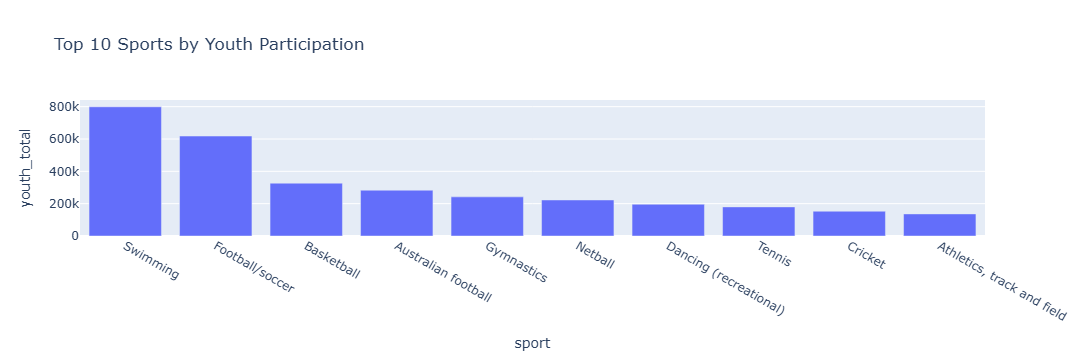

In [13]:
fig = px.bar(
 top_youth_sports_df.head(10),
 x="sport",
 y="youth_total",
 title="Top 10 Sports by Youth Participation"
)

fig.show()

### Visualisation 2: Youth concentration and adolescent retention:

This scatterplot compares youth concentration with adolescent retention. Sports positioned higher on adolescent retention may be more useful for long-term fan development because a greater share of their youth participants are in the 12–14 age group. For ASC, this matters because the goal is not only to reach children once, but to build a steady and sustained interest before Brisbane 2032. The spread of sports in this chart supports the decision to use clustering, because sports show different combinations of youth concentration and retention.

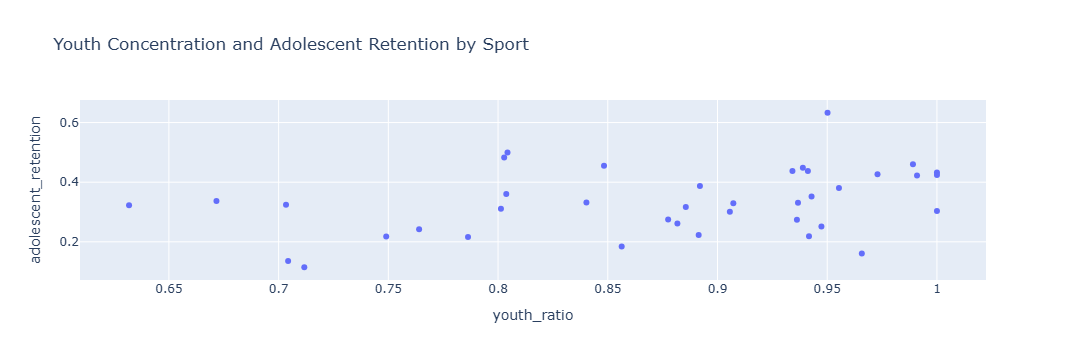

In [14]:
fig = px.scatter(
 meaningful_youth_df,
 x="youth_ratio",
 y="adolescent_retention",
 hover_name="sport",
 title="Youth Concentration and Adolescent Retention by Sport"
)

fig.show()

### Visualisation 3: Combined youth participation profile:

This scatterplot compares youth concentration and adolescent retention for sports with a meaningful youth participation base. The size of each point represents total youth participation, while colour represents gender balance. This visualisation helps compare the main structured variables together before clustering. It supports the structured question by showing which sports combine stronger youth concentration, stronger adolescent retention, larger youth participation, and more balanced gender participation.

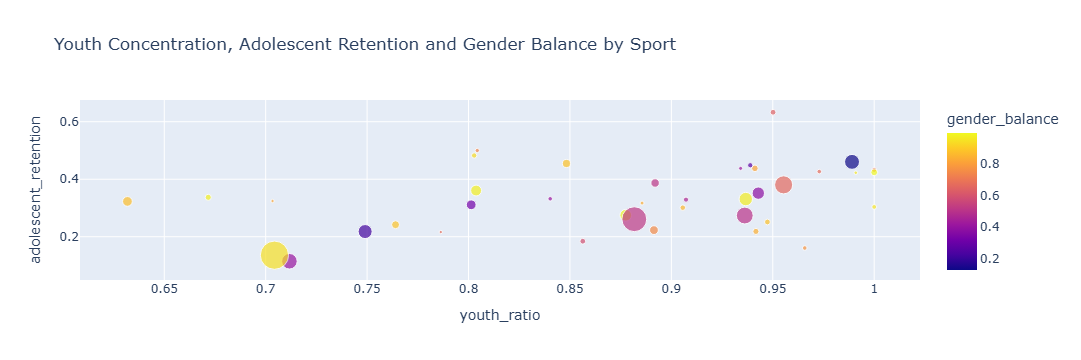

In [15]:
fig = px.scatter(
 meaningful_youth_df,
 x="youth_ratio",
 y="adolescent_retention",
 size="youth_total",
 color="gender_balance",
 hover_name="sport",
 title="Youth Concentration, Adolescent Retention and Gender Balance by Sport"
)

fig.show()

The scatterplot shows that youth engagement strength is not based on one measure alone. Some sports have high youth concentration but lower adolescent retention, while others show stronger retention or larger youth participation bases.

For ASC, this means priority sports should not be selected only by total participation. Sports with stronger youth concentration, adolescent retention, and gender balance may provide better long-term youth engagement opportunities, while sports with weaker balance may require targeted inclusion strategies.

## Pre-clustering structured analysis summary:

The structured analysis shows that youth sport prioritisation should not be based only on the largest participation totals. A high-quality recommendation for ASC should consider several participation characteristics together:

- sports with a large youth participation base,
- sports where children and young adolescents make up a strong share of participants,
- sports where participation continues into the 12–14 age group,
- and sports with more balanced participation between males and females.

This prepares the dataset for the next stage of analysis, where clustering can be used to group sports with similar youth participation profiles. This will help ASC think in terms of different strategic groups of sports rather than one simple ranked list.

# Deeper Analysis: Clustering Sports by Youth Participation Profile:

The previous section ranked sports using individual variables. However, ASC needs a more strategic view than separate rankings. Clustering is used to group sports with similar youth participation profiles.

This section uses the engineered variables:

- youth_total
- youth_ratio
- adolescent_retention
- gender_balance

Before clustering, the values are scaled using min-max scaling so that large values such as youth_total do not dominate smaller ratio-based variables.

In [16]:
# Selecting columns for clustering
cluster_columns = ["youth_total","youth_ratio","adolescent_retention","gender_balance"]
cluster_df = structured_analysis_df[["sport"] + cluster_columns]
cluster_df.head()

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance
0,Adventure racing,7503.477723,0.694664,0.148918,0.978230
1,Air sports,8342.603488,0.667797,0.419551,0.540245
2,Archery,5379.755633,0.753074,0.568389,0.666060
3,"Athletics, track and field",136658.053740,0.877509,0.274800,0.997187
4,Australian football,283390.828971,0.936191,0.273732,0.503256


In [17]:
# Removing rows with missing values in the clustering columns
cluster_df = cluster_df.dropna(subset=cluster_columns)
cluster_df.head()

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance
0,Adventure racing,7503.477723,0.694664,0.148918,0.978230
1,Air sports,8342.603488,0.667797,0.419551,0.540245
2,Archery,5379.755633,0.753074,0.568389,0.666060
3,"Athletics, track and field",136658.053740,0.877509,0.274800,0.997187
4,Australian football,283390.828971,0.936191,0.273732,0.503256


In [18]:
# Scale the clustering columns
scaled_cluster_data = minmax_scale(cluster_df[cluster_columns])
scaled_cluster_data.shape

(116, 4)

## Applying KMeans clustering:

KMeans clustering is used to group sports into three clusters. Three clusters are used because this gives ASC a simple strategic grouping: sports with stronger, moderate, and weaker youth engagement profiles.

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(scaled_cluster_data)
cluster_df.head()

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance,cluster
0,Adventure racing,7503.477723,0.694664,0.148918,0.978230,0
1,Air sports,8342.603488,0.667797,0.419551,0.540245,0
2,Archery,5379.755633,0.753074,0.568389,0.666060,1
3,"Athletics, track and field",136658.053740,0.877509,0.274800,0.997187,1
4,Australian football,283390.828971,0.936191,0.273732,0.503256,1


The clustered data is reviewed to understand which sports have been grouped together. This helps interpret the meaning of each cluster in relation to ASC’s youth fan engagement objective.

In [20]:
cluster_df.sort_values(by="cluster").head(20)

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance,cluster
0,Adventure racing,7503.477723,0.694664,0.148918,0.978230,0
1,Air sports,8342.603488,0.667797,0.419551,0.540245,0
10,Billiards/Snooker/Pool,1031.022171,0.477805,0.000000,0.948925,0
8,Baton twirling,1387.661532,0.428463,0.235338,0.349988,0
36,Eight ball,1024.436388,0.496838,0.000000,0.993677,0
44,Football/soccer,618174.829863,0.881727,0.261047,0.520937,0
51,Gymnastics,242049.075452,0.711707,0.114685,0.406925,0
94,Pony Club,4713.480801,0.795048,0.173962,0.578564,0
122,Synchronised swimming,2643.264995,0.568591,0.318548,0.774751,0
120,Swimming,799135.077742,0.704328,0.135846,0.946968,0


In [21]:
# Counting the number of sports in each cluster
cluster_counts_df = cluster_df.groupby(["cluster"]).size().reset_index(name="count")
cluster_counts_df

,cluster,count
0,0,13
1,1,62
2,2,41


The average values for each cluster are calculated. This helps describe the main characteristics of each group of sports.

In [22]:
cluster_summary_df = cluster_df.groupby(["cluster"])[cluster_columns].mean()
cluster_summary_df

,youth_total,youth_ratio,adolescent_retention,gender_balance
cluster,,,,
0,137576.611341,0.594096,0.178452,0.685370
1,31571.751584,0.891075,0.427129,0.777908
2,20580.970102,0.941574,0.384651,0.157428


## Cluster interpretation:

The cluster summary shows three different youth participation profiles.

**Cluster 0** has the highest average youth participation total, but lower youth concentration and lower adolescent retention. This suggests that these sports may have large existing youth audiences, but ASC should not assume they automatically provide the strongest long-term engagement pathway.

**Cluster 1** has a stronger overall balance. It has a high youth ratio, the strongest adolescent retention, and the strongest gender balance. For ASC, this cluster may be particularly useful for sustained and inclusive youth fan engagement because young people appear more likely to remain involved into the 12–14 age group.

**Cluster 2** has the highest youth ratio but the weakest gender balance. These sports may have concentrated youth participation, but ASC would need to consider more targeted inclusion strategies before using them as broad youth engagement priorities.

This clustering does not produce an automatic final priority list. Instead, it gives ASC a leadership-level way to compare different types of sports and design different engagement strategies for each group.

In [23]:
# Merging the cluster results with the structured analysis dataframe
structured_clustered_df = structured_analysis_df.merge(cluster_df[["sport", "cluster"]],on="sport",how="inner")
structured_clustered_df.head()

,sport,males,females,5-8,9-11,12-14,total_participants,youth_total,youth_ratio,adolescent_retention,gender_balance,cluster
0,Adventure racing,5283.216118,5518.369871,5010.809389,1375.268806,1117.399529,10801.585990,7503.477723,0.694664,0.148918,0.978230,0
1,Air sports,9118.155065,3374.564498,4842.457771,0.000000,3500.145717,12492.719563,8342.603488,0.667797,0.419551,0.540245,0
2,Archery,4764.652719,2379.077502,1123.266402,1198.697779,3057.791452,7143.730221,5379.755633,0.753074,0.568389,0.666060,1
3,"Athletics, track and field",78086.015532,77648.012444,53332.220154,45772.153889,37553.679697,155734.027976,136658.053740,0.877509,0.274800,0.997187,1
4,Australian football,226536.937876,76169.350409,121991.556433,83826.252144,77573.020394,302706.288285,283390.828971,0.936191,0.273732,0.503256,1


## Sports in each cluster:

The following outputs show the sports in each cluster. This makes it easier to interpret the clusters and connect them to ASC’s youth engagement planning.

In [24]:
structured_clustered_df[structured_clustered_df["cluster"] == 0][["sport","youth_total","youth_ratio","adolescent_retention","gender_balance"]].sort_values(by="youth_total", ascending=False).head(10)

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance
98,Swimming,799135.077742,0.704328,0.135846,0.946968
37,Football/soccer,618174.829863,0.881727,0.261047,0.520937
43,Gymnastics,242049.075452,0.711707,0.114685,0.406925
110,Walking (Recreational),94604.753457,0.631846,0.322829,0.875183
1,Air sports,8342.603488,0.667797,0.419551,0.540245
0,Adventure racing,7503.477723,0.694664,0.148918,0.978230
115,Yoga,4846.280878,0.458287,0.189149,0.625646
77,Pony Club,4713.480801,0.795048,0.173962,0.578564
79,Ready Steady Go Kids,3039.982939,0.206150,0.000000,0.369767
99,Synchronised swimming,2643.264995,0.568591,0.318548,0.774751


In [25]:
structured_clustered_df[structured_clustered_df["cluster"] == 1][["sport","youth_total","youth_ratio","adolescent_retention","gender_balance"]].sort_values(by="youth_total", ascending=False).head(10)

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance
7,Basketball,326756.192889,0.955347,0.380485,0.664020
4,Australian football,283390.828971,0.936191,0.273732,0.503256
103,Tennis,180086.975223,0.936677,0.331054,0.974096
3,"Athletics, track and field",136658.053740,0.877509,0.274800,0.997187
86,Running/jogging,118233.788008,0.803745,0.360731,0.979371
52,Karate,77090.316845,0.891416,0.223022,0.751293
84,Rugby league,72239.715753,0.891987,0.386949,0.515579
34,Fitness/Gym,65213.519932,0.848288,0.454755,0.885614
23,Cycling,63435.695534,0.764022,0.241880,0.888106
105,Touch football,46063.706243,1.000000,0.424078,0.999130


In [26]:
structured_clustered_df[structured_clustered_df["cluster"] == 2][["sport","youth_total","youth_ratio","adolescent_retention","gender_balance"]].sort_values(by="youth_total", ascending=False).head(10)

,sport,youth_total,youth_ratio,adolescent_retention,gender_balance
65,Netball,222814.895240,0.989070,0.460451,0.129511
25,Dancing (recreational),196500.557520,0.749033,0.217985,0.219235
21,Cricket,153323.874826,0.942858,0.351670,0.382374
24,DanceSport,95588.582293,0.801320,0.311133,0.322778
85,Rugby union,28306.104650,0.938897,0.448610,0.266795
6,Baseball,26775.036503,0.907217,0.328977,0.468658
40,Golf,20566.337381,0.840264,0.331967,0.415141
15,Boxing,16368.819698,0.934147,0.437796,0.425946
71,Parkour,9750.369299,0.942113,0.185969,0.358152
33,Fishing (recreational),8733.532670,1.000000,0.283484,0.427007


## Cluster visualisations:

Visualisation is important because ASC stakeholders may find it easier to interpret grouped patterns visually rather than through tables alone.

The following visualisations show how sports are distributed across the clusters based on youth participation characteristics. This helps communicate the differences between sports with stronger youth participation profiles and those with weaker or more specialised participation patterns.

## Cluster distribution:

The first visualisation shows the number of sports in each cluster. This provides a simple overview of how the sports were grouped by the clustering process.

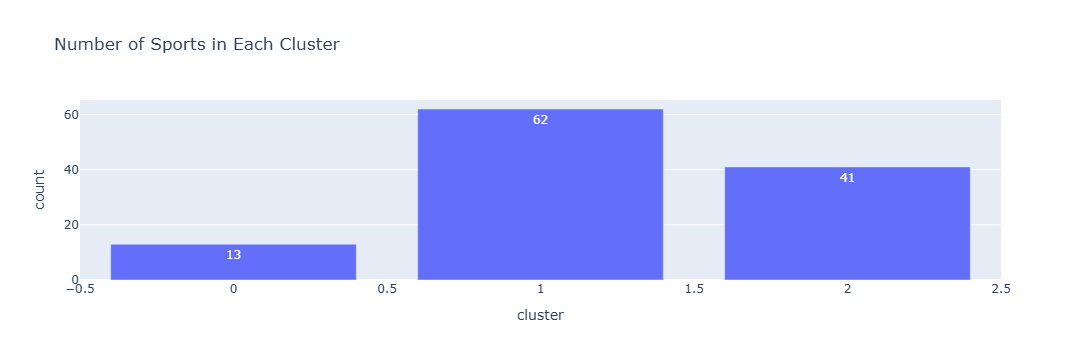

In [27]:
fig = px.bar(
 cluster_counts_df,
 x="cluster",
 y="count",
 text_auto=True,
 title="Number of Sports in Each Cluster"
)

fig.show()

## Youth participation by cluster:

The next visualisation compares sports using youth participation totals and youth participation ratios.

- The horizontal axis shows the estimated number of participants aged 5–14.
- The vertical axis shows the proportion of participants who are aged 5–14.
- Different colours represent the clusters.

This helps ASC identify which sports combine both large youth participation and strong youth concentration.

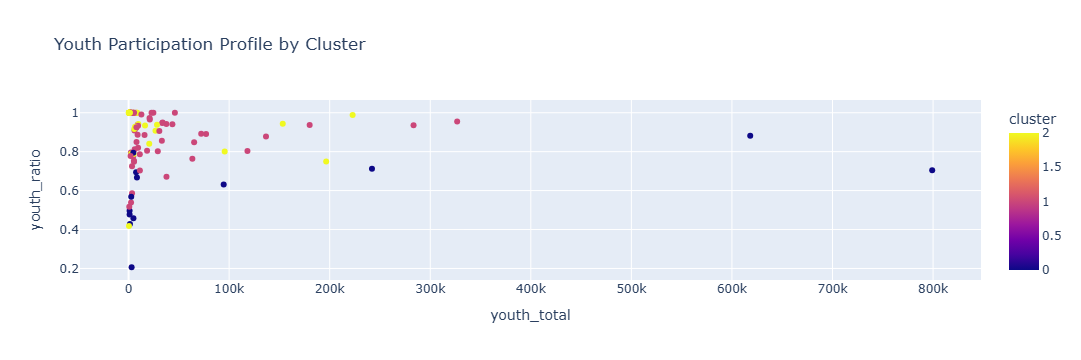

In [28]:
fig = px.scatter(
 structured_clustered_df,
 x="youth_total",
 y="youth_ratio",
 color="cluster",
 hover_name="sport",
 title="Youth Participation Profile by Cluster"
)

fig.show()

## Adolescent retention and gender balance:

The next visualisation compares sports using adolescent retention and gender balance.

- The horizontal axis shows adolescent retention.
- The vertical axis shows gender balance.
- Different colours represent the clusters.

This is useful because ASC may want to prioritise sports where participation continues into adolescence and where participation is more balanced across males and females.

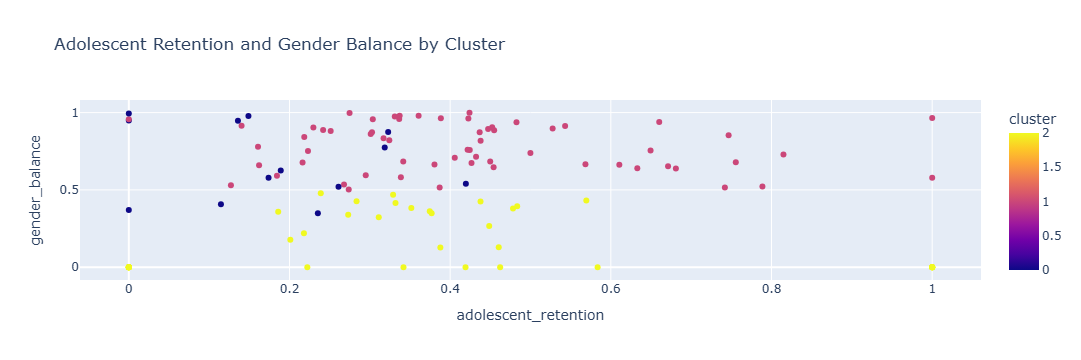

In [29]:
fig = px.scatter(
 structured_clustered_df,
 x="adolescent_retention",
 y="gender_balance",
 color="cluster",
 hover_name="sport",
 title="Adolescent Retention and Gender Balance by Cluster"
)

fig.show()

## Structured visualisation insights:

The visualisations show that sports are not evenly distributed across the participation variables. Some sports combine large youth participation with strong youth concentration, while others may show stronger adolescent retention or more balanced participation across gender.

These differences are important for ASC because a successful Brisbane 2032 youth engagement strategy may require different approaches for different types of sports. For example:

- sports with large youth participation may support broad engagement campaigns,
- sports with strong adolescent retention may support long-term fan development,
- and sports with stronger gender balance may support more inclusive engagement strategies.

However, participation data alone does not explain how sports are represented publicly or how media narratives may influence youth engagement. Therefore, the next stage analyses semi-structured Guardian article data to explore sport-related narratives connected to Brisbane 2032, athletes, and youth engagement.

## Ethical considerations for structured data:

## 1. Representation and fairness in youth participation data:

The structured AusPlay data provides useful participation estimates, but it may not fully represent all children and young people equally. Participation can be influenced by access to facilities, family income, transport, school opportunities, disability access, cultural background, gender expectations, and regional location. This means that sports with lower participation should not automatically be treated as less important. A lower youth_total may reflect barriers to participation rather than lack of interest.

For ASC, this is important because using participation numbers alone could reinforce existing inequalities. Sports that already have strong access and visibility may receive more support, while smaller or less accessible sports may be overlooked.

## 2. Risk of over-prioritising already popular sports:

The analysis ranks and clusters sports using participation patterns. This is useful for identifying strong youth engagement opportunities, but it also creates an ethical risk. If ASC only prioritises sports that already have high participation, it may strengthen the dominance of popular sports and reduce attention to emerging, minority, or less visible Olympic-relevant sports.

This matters because Brisbane 2032 should not only promote the sports that are already popular. It should also create opportunities for a wider range of young people to discover different sports, athletes, and Olympic pathways.

## 3. Gender balance and inclusion:

The gender_balance variable is included to help consider inclusiveness. However, this measure is only a simple estimate based on male and female participation counts. It does not capture all gender identities, nor does it explain why gender imbalance exists in some sports. Therefore, gender_balance should be interpreted carefully. A sport with uneven participation should not be dismissed. Instead, it may indicate where ASC and sporting organisations could design more inclusive programs, role-model campaigns, or targeted engagement strategies.

## 4. Transparency and explainability:
Clusters depend on the selected variables, scaling method, and number of clusters chosen. ASC should treat the results as decision-support evidence rather than automatic recommendations.

## Structured analysis summary:

The clustering stage extends the structured analysis by grouping sports based on multiple participation characteristics at the same time. This is more useful for ASC than a single ranked list because it shows that sports may be strategically different. For example, one group may contain sports with a large youth participation base, while another may contain sports with stronger youth concentration, adolescent retention, or gender balance. These differences matter because ASC may need different engagement strategies for different groups of sports before Brisbane 2032. Sports with large youth participation may support broad-reach campaigns, while sports with stronger retention and gender balance may support more sustained and inclusive youth engagement. The cluster visualisations help communicate these differences more clearly to stakeholders by showing how sports vary across youth participation, youth concentration, adolescent retention, and gender balance.

# Semi-Structured Analysis:

The structured analysis used AusPlay data to identify sports with stronger youth participation patterns. However, ASC’s youth fan engagement strategy for Brisbane 2032 should not be based only on participation numbers. Fan engagement is also shaped by the stories and public narratives that children, families, schools, and communities encounter through media.

For this reason, the second analytics cycle uses Guardian article data to explore how Brisbane 2032, Olympic and Paralympic sport, athletes, youth, and participation are represented in public media coverage.

This cycle follows the same QDAVI structure:

- **Question**: define the media narrative question.
- **Data**: retrieve, clean, and prepare Guardian article data.
- **Analysis**: apply text analytics techniques.
- **Visualisation**: communicate word and topic patterns.
- **Insights**: connect media narratives back to ASC’s youth engagement objective.

## Semi-structured data question:

**What media narratives appear in Guardian coverage related to Brisbane 2032, Olympic/Paralympic sport, athletes, youth, and participation, and how can these narratives support ASC’s youth fan engagement strategy?**

## Justification:

This question supports the main analysis question by focusing on the communication side of the ASC problem. The structured analysis helps identify where youth participation strength already exists. The semi-structured analysis helps identify which public-facing narratives may support long-term fan interest before Brisbane 2032. For ASC leadership, building youth fan engagement is not only a participation issue. It is also a storytelling and communication issue. Young people may become more interested in sport when they can connect participation with athlete stories, Olympic pathways, local Brisbane 2032 identity, school and community sport, and inclusive national sporting narratives. This analysis therefore investigates Guardian article text to identify recurring words and themes that may help ASC understand how Brisbane 2032 and sport are being publicly framed. These themes can later be compared with the structured participation findings to develop stronger stakeholder recommendations.

## Techniques selected for this cycle

This semi-structured cycle uses three text analytics techniques taught in the unit:

1. **CountVectorizer** is used to identify common repeated words in the filtered article collection.
2. **TF-IDF** is used to identify words that are more distinctive across the article collection.
3. **NMF topic modelling** is used to group related words into possible media narrative themes.

These techniques are appropriate because the question is focused on article text, language, and themes rather than only numerical participation patterns.

## Ethical note at the question stage

Guardian article data should be interpreted carefully. Media coverage reflects editorial choices and may overrepresent some sports, athletes, political issues, or public controversies while underrepresenting others. Therefore, this analysis does not treat Guardian coverage as a complete measure of public opinion or youth interest.

Instead, the Guardian data is used as one source of media narrative evidence. The results will be combined with the structured AusPlay analysis and interpreted cautiously for ASC decision-making.

# Data

The semi-structured data for this cycle comes from Guardian articles retrieved through the Guardian API. This data is suitable because the analysis is focused on article text, public media language, and possible narratives related to Brisbane 2032 and sport.

The Guardian API returns data in JSON format. This means the article records are stored as nested dictionaries and lists rather than in a simple table. The article data is therefore retrieved, extracted, saved, and converted into a dataframe before text analysis.

In [30]:
# load your personal API key
with open('guardian_key.txt', 'r') as file:
 key = file.read().strip()

len(key)

36

In [31]:
# build a focused Guardian API search URL
base_url = 'https://content.guardianapis.com/'
search_string = '("Brisbane 2032" OR "Olympic" OR "Australian athletes" OR "young athletes" OR "youth sport") AND ("swimming" OR "football" OR "basketball" OR "gymnastics" OR "tennis" OR "athletics")'
production_office = "aus"
from_date = "2021-07-21"
section = "sport"

full_url = base_url + f"search?q={search_string}&section={section}&production-office={production_office}&from-date={from_date}&order-by=relevance&show-fields=headline,trailText,bodyText&api-key={key}"

print(full_url[:120])

https://content.guardianapis.com/search?q=("Brisbane 2032" OR "Olympic" OR "Australian athletes" OR "young athletes" OR 


The Guardian API search is focused on sports that were important in the structured AusPlay analysis, including swimming, football/soccer, basketball, gymnastics, tennis, and athletics. These sports were selected because they showed stronger youth participation patterns and are relevant to ASC’s youth fan engagement objective.

The search is also restricted to the Guardian sport section and ordered by relevance. This improves the quality of the semi-structured dataset by reducing broad political, infrastructure, and general news articles that do not directly support the media narrative question.

In [32]:
# get data from server
server_response = requests.get(full_url, timeout=30)
server_data = server_response.json()
resp_data = server_data.get('response','')
if resp_data == '':
 print("ERROR obtaining results:", server_data)
else:
 print("SUCCESS!")
 print(f"{resp_data['total']} results found available in {resp_data['pages']} pages")
 print(f"{resp_data['pageSize']} results per page")
 results = resp_data.get('results',[])

SUCCESS!
538 results found available in 54 pages
10 results per page


In [33]:
# display keys available in the first result
results[0].keys()

dict_keys(['id', 'type', 'sectionId', 'sectionName', 'webPublicationDate', 'webTitle', 'webUrl', 'apiUrl', 'fields', 'isHosted', 'pillarId', 'pillarName'])

In [34]:
# check the number of pages
num_pages = resp_data['pages']
num_pages

54

## Extracting article text

The Guardian API returns article information as semi-structured JSON data. The following function extracts the article title, publication date, headline, trail text, and body text from each article result.

The headline and trail text are included because they often summarise the main media narrative of an article. This makes them useful for analysing how Brisbane 2032, sport, athletes, and youth engagement are framed in public media coverage.

In [35]:
def articles_from_page_results(page_results):
 articles = {}
 
 for result in page_results:
 article_date = result['webPublicationDate']
 article_title = result['webTitle'] + f" [{article_date}]" 
 headline = result["fields"].get("headline", "")
 trail_text = result["fields"].get("trailText", "")
 body_text = result["fields"].get("bodyText", "")
 article_text = headline + " " + trail_text + " " + body_text
 articles[article_title] = article_text
 
 return articles

Because the Guardian API search can return a large number of articles, this analysis retrieves a focused sample of the first 500 articles returned by the search query. This keeps the dataset large enough for text analytics while avoiding unnecessary retrieval of thousands of articles.

This sample is treated as a focused media sample, not a complete representation of all Guardian coverage. The results are therefore interpreted cautiously and used as supporting narrative evidence for ASC decision-making.

In [36]:
def get_limited_articles_for_response(response_json, full_url, max_articles):
 
 articles = {}
 num_pages = response_json['pages']
 page = 1
 while page <= num_pages and len(articles) < max_articles:
 
 try:
 print("Retrieving page:", page)
 page_response = requests.get(full_url + f"&page={page}", timeout=30)
 page_data = page_response.json()
 page_resp_data = page_data.get('response', '')
 if page_resp_data == '':
 print("ERROR obtaining page:", page)
 break
 
 page_results = page_resp_data.get('results', [])
 page_articles = articles_from_page_results(page_results)
 articles.update(page_articles)
 print("Articles retrieved so far:", len(articles))
 page = page + 1
 
 except requests.exceptions.Timeout:
 print("ERROR: Request timed out on page", page)
 break
 
 except requests.exceptions.RequestException as error:
 print("ERROR: Request failed on page", page, error)
 break
 
 limited_articles = dict(list(articles.items())[:max_articles])
 print(len(limited_articles), "articles are retrieved.")
 
 return limited_articles

In [37]:
# retrieve first 500 relevant Guardian articles
guardian_articles = get_limited_articles_for_response(resp_data, full_url, 500)

Retrieving page: 1
Articles retrieved so far: 10
Retrieving page: 2
Articles retrieved so far: 20
Retrieving page: 3
Articles retrieved so far: 30
Retrieving page: 4
Articles retrieved so far: 40
Retrieving page: 5
Articles retrieved so far: 50
Retrieving page: 6
Articles retrieved so far: 60
Retrieving page: 7
Articles retrieved so far: 70
Retrieving page: 8
Articles retrieved so far: 80
Retrieving page: 9
Articles retrieved so far: 90
Retrieving page: 10
Articles retrieved so far: 100
Retrieving page: 11
Articles retrieved so far: 110
Retrieving page: 12
Articles retrieved so far: 120
Retrieving page: 13
Articles retrieved so far: 130
Retrieving page: 14
Articles retrieved so far: 140
Retrieving page: 15
Articles retrieved so far: 150
Retrieving page: 16
Articles retrieved so far: 160
Retrieving page: 17
Articles retrieved so far: 170
Retrieving page: 18
Articles retrieved so far: 180
Retrieving page: 19
Articles retrieved so far: 190
Retrieving page: 20
Articles retrieved so far: 20

## Saving retrieved articles

The retrieved Guardian articles are saved as a JSON file in the same folder as the notebook. This avoids repeatedly calling the API every time the notebook is run and keeps the later analysis more stable.

In [38]:
# save retrieved articles to JSON file in the same folder as the notebook
file_name = "brisbane_2032_youth_sport_articles.json"
with open(file_name, 'w', encoding='utf-8') as fp:
 fp.write(json.dumps(guardian_articles))

len(guardian_articles)

500

# Analysis:

The Guardian articles have been retrieved and saved as a JSON file. The next step is to read the saved JSON file and convert it into a dataframe. This prepares the article data for text analysis. The dataframe will include the article title and article text, which can later be used for CountVectorizer, TF-IDF, and topic modelling.

In [39]:
# read saved Guardian articles JSON file
file_name = "brisbane_2032_youth_sport_articles.json"
with open(file_name, 'r', encoding='utf-8') as file:
 guardian_articles = json.load(file)

len(guardian_articles)

500

## Converting article dictionary to dataframe

The saved Guardian articles are stored as a dictionary, where each key is the article title and each value is the article text. To analyse the articles more easily, the dictionary is converted into a dataframe.

In [40]:
article_records = []
for title in guardian_articles.keys():
 
 article_record = {
 "title": title,
 "text": guardian_articles[title]
 }
 
 article_records.append(article_record)

guardian_df = pd.DataFrame(article_records)
guardian_df.head()

,title,text
0,Andrew Dillon reveals AFL’s Olympic-sized ambi...,Andrew Dillon reveals AFL’s Olympic-sized ambi...
1,Relay team grab bronze at worlds on another re...,Relay team grab bronze at worlds on another re...
2,"Gout and Kennedy renew rivalry, Hull eyes his...","Gout and Kennedy renew rivalry, Hull eyes his..."
3,"Gout Gout may be bigger than Cathy Freeman, bu...","Gout Gout may be bigger than Cathy Freeman, bu..."
4,Two Australians created a defining Olympic mom...,Two Australians created a defining Olympic mom...


In [41]:
guardian_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   500 non-null    str  
 1   text    500 non-null    str  
dtypes: str(2)
memory usage: 7.9 KB


## Cleaning article text

The article title and text are cleaned before analysis. This includes removing missing values and converting text to lowercase. This makes the text more consistent for later text analysis.

In [42]:
# remove rows with missing title or text
guardian_df = guardian_df.dropna(subset=["title", "text"])

# convert title and text to lowercase
guardian_df["title"] = guardian_df["title"].str.lower()
guardian_df["text"] = guardian_df["text"].str.lower()

guardian_df.head()

,title,text
0,andrew dillon reveals afl’s olympic-sized ambi...,andrew dillon reveals afl’s olympic-sized ambi...
1,relay team grab bronze at worlds on another re...,relay team grab bronze at worlds on another re...
2,"gout and kennedy renew rivalry, hull eyes his...","gout and kennedy renew rivalry, hull eyes his..."
3,"gout gout may be bigger than cathy freeman, bu...","gout gout may be bigger than cathy freeman, bu..."
4,two australians created a defining olympic mom...,two australians created a defining olympic mom...


In [43]:
# check missing values after cleaning
guardian_df.isna().sum()

title    0
text     0
dtype: int64

## Filtering articles for relevance

The Guardian API retrieved a large number of articles, so the article collection needs to be filtered before text analysis. The filtering is designed to match the main analytical question for ASC.

Articles are kept only when they connect to both:

1. the Brisbane 2032 or Olympic context, and 
2. sport, athletes, youth, schools, children, or participation.

This is stricter than using a single keyword match. It helps ensure that the semi-structured analysis focuses on articles that are more relevant to ASC’s youth fan engagement planning before Brisbane 2032.

In [44]:
# combine title and text into one column for filtering
guardian_df["combined_text"] = guardian_df["title"] + " " + guardian_df["text"]

# filter for articles more directly connected to Brisbane 2032 or Olympic context
brisbane_2032_filter = (
 guardian_df["combined_text"].str.contains("brisbane 2032") |
 (
 guardian_df["combined_text"].str.contains("brisbane") &
 guardian_df["combined_text"].str.contains("2032")
 ) |
 (
 guardian_df["combined_text"].str.contains("2032") &
 guardian_df["combined_text"].str.contains("olympic")
 ) |
 (
 guardian_df["combined_text"].str.contains("2032") &
 guardian_df["combined_text"].str.contains("paralympic")
 )
)

# filter for articles connected to sport, athletes, youth, schools, or participation
engagement_filter = (
 guardian_df["combined_text"].str.contains("sport") |
 guardian_df["combined_text"].str.contains("athlete") |
 guardian_df["combined_text"].str.contains("youth") |
 guardian_df["combined_text"].str.contains("children") |
 guardian_df["combined_text"].str.contains("school") |
 guardian_df["combined_text"].str.contains("participation")
)

# keep only articles that satisfy both filters
relevant_guardian_df = guardian_df[
 brisbane_2032_filter & engagement_filter
]

relevant_guardian_df.shape

(69, 3)

In [45]:
relevant_guardian_df.head()

,title,text,combined_text
0,andrew dillon reveals afl’s olympic-sized ambi...,andrew dillon reveals afl’s olympic-sized ambi...,andrew dillon reveals afl’s olympic-sized ambi...
2,"gout and kennedy renew rivalry, hull eyes his...","gout and kennedy renew rivalry, hull eyes his...","gout and kennedy renew rivalry, hull eyes his..."
3,"gout gout may be bigger than cathy freeman, bu...","gout gout may be bigger than cathy freeman, bu...","gout gout may be bigger than cathy freeman, bu..."
4,two australians created a defining olympic mom...,two australians created a defining olympic mom...,two australians created a defining olympic mom...
5,"eight australian athletes to watch, eight year...","eight australian athletes to watch, eight year...","eight australian athletes to watch, eight year..."


The filtered article count is much smaller than the original Guardian article collection. This is useful because the text analysis should focus on articles that are relevant to the ASC scenario, rather than being dominated by broad or unrelated media coverage.

This filtering decision also has a limitation. Some relevant articles may be excluded if they discuss youth sport or Brisbane 2032 using different wording. Therefore, the filtered dataset should be treated as a focused sample for analysis, not as a complete representation of all public media narratives.

## Semi-structured data preparation summary:

The Guardian article data has now been retrieved, saved, converted into a dataframe, cleaned, and filtered for relevance to the ASC Brisbane 2032 scenario. The API search returned 538 available articles, a focused sample of 500 articles was retrieved, and the relevance filter reduced the dataset to 69 articles most connected to Brisbane 2032, Olympic sport, athletes, youth, schools, or participation.

This filtering step improves the quality of the later text analysis because it reduces the influence of broad or unrelated articles. However, it also creates a limitation: some relevant articles may be excluded if they use different wording. Therefore, the filtered dataset should be treated as a focused Guardian media sample, not as a complete representation of all public media narratives.

# CountVectorizer Analysis

CountVectorizer is used to identify commonly occurring words in the filtered Guardian article text. This supports the main analytical question by showing which sport-related and Olympic-related terms appear frequently in public media narratives.

For ASC, this is useful because repeated terms may indicate the narratives and themes that young people, families, and sport stakeholders are likely to encounter in media coverage before Brisbane 2032.

The initial word outputs were dominated by general Guardian reporting terms, including time-zone labels, update labels, reporting verbs, and broad political words. These terms do not help answer the ASC youth engagement question.

A small custom stop-word list is therefore used to remove high-frequency but low-value words. This keeps the analysis focused on sport, Olympic, athlete, youth, venue, participation, and community-related language.

In [46]:
custom_stop_words = [
 "gmt", "updated", "says", "said", "say", "new", "just", "time",
 "people", "government", "minister", "state", "police", "today",
 "ve", "like", "years", "year", "australia", "australian",
 "queensland", "brisbane", "2032", "they", "their", "them", "his", "her", "she", "he", "you", "your",
 "we", "our", "us", "i", "me", "my", "it", "its",
 "more", "about", "after", "before", "had", "has", "have",
 "which", "what", "were", "was", "are", "is", "be", "been",
 "so", "out", "can", "or", "and", "but", "all", "not", "no",
 "this", "that", "these", "those", "there", "here", "then",
 "than", "when", "where", "who", "how", "why","up", "down", "two", "three", "four", "would", "could", "should",
"also", "first", "last", "into", "onto", "over", "under",
"back", "still", "much", "many"
]

In [47]:
count_vectorizer = CountVectorizer(max_df=0.8,min_df=2,max_features=1000,stop_words=custom_stop_words)
count_vector = count_vectorizer.fit_transform(relevant_guardian_df["combined_text"])
count_vector.shape

(69, 1000)

In [48]:
# get feature names
count_words = count_vectorizer.get_feature_names_out()
count_df = pd.DataFrame(count_vector.toarray(),columns=count_words)
count_df.head()

,00,000,03,04,07,08,10,100,100m,11,...,work,worked,working,world,wouldn,yesterday,yet,young,younger,zealand
0,0,3,1,0,0,0,2,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,1,0,0,1,0,0,1,0,2,0,...,0,0,0,7,0,0,0,1,1,0
2,1,2,0,1,0,0,4,0,3,0,...,0,0,0,1,0,0,3,0,0,0
3,1,0,0,0,0,0,2,0,0,0,...,5,0,1,1,0,0,2,1,0,0
4,1,0,0,0,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,2,0


In [49]:
# calculate total word counts
word_counts = count_df.sum().sort_values(ascending=False)

# convert word counts to dataframe
word_counts_df = word_counts.reset_index()
word_counts_df.columns = ["word", "count"]

word_counts_df.head(20)

,word,count
0,world,245
1,sport,215
2,gout,203
3,gold,197
4,athletics,180
5,athletes,174
6,tokyo,152
7,team,141
8,medal,134
9,sports,134


## Visualising common words

The most common words are visualised using a bar chart. This makes it easier to interpret the dominant terms in the Guardian article data.

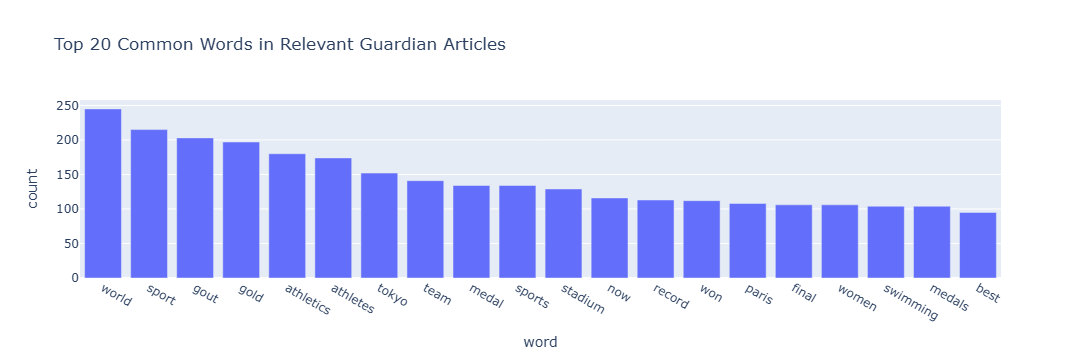

In [50]:
fig = px.bar(
 word_counts_df.head(20),
 x="word",
 y="count",
 title="Top 20 Common Words in Relevant Guardian Articles"
)

fig.show()

### Interpretation:

The CountVectorizer results show that the filtered Guardian articles are strongly shaped by Olympic and sport performance language. Frequent terms such as world, sport, gold, athletics, athletes, team, medal, stadium and record suggest that the article collection is focused on elite sport, athlete achievement, competition outcomes, and event infrastructure.

For ASC, this is useful because these terms point to media narratives that can support youth fan engagement. Athlete achievement and medal narratives can help create role models for young people, while stadium and event-related terms can connect youth interest to the local Brisbane 2032 context.

However, word counts alone do not show which terms are most distinctive across articles. Therefore, TF-IDF is used next to identify words that have stronger relative importance in the filtered article collection.

# TF-IDF Analysis:

TF-IDF is used to identify words that are important within the filtered Guardian article collection. While CountVectorizer shows the most frequent words, TF-IDF gives more weight to words that are distinctive across the articles.

This is useful for ASC because distinctive words may reveal stronger media narratives connected to Brisbane 2032, athletes, sport, youth, and Olympic engagement.

In [51]:
tfidf_vectorizer = TfidfVectorizer(max_df=0.8,min_df=2,max_features=1000,stop_words=custom_stop_words)
tfidf_vector = tfidf_vectorizer.fit_transform(relevant_guardian_df["combined_text"])
tfidf_vector.shape

(69, 1000)

In [52]:
tfidf_words = tfidf_vectorizer.get_feature_names_out()
tfidf_words[:20]

array(['00', '000', '03', '04', '07', '08', '10', '100', '100m', '11',
       '12', '13', '14', '15', '1500m', '16', '17', '18', '19', '20'],
      dtype=object)

In [53]:
tfidf_df = pd.DataFrame(tfidf_vector.toarray(),columns=tfidf_words)
tfidf_df.head()

,00,000,03,04,07,08,10,100,100m,11,...,work,worked,working,world,wouldn,yesterday,yet,young,younger,zealand
0,0.000000,0.136641,0.054631,0.000000,0.0,0.000000,0.078693,0.0,0.000000,0.000000,...,0.040929,0.0,0.000000,0.000000,0.062646,0.0,0.000000,0.000000,0.000000,0.0
1,0.021042,0.000000,0.000000,0.030136,0.0,0.000000,0.021042,0.0,0.047631,0.000000,...,0.000000,0.0,0.000000,0.091848,0.000000,0.0,0.000000,0.023815,0.033502,0.0
2,0.025335,0.058655,0.000000,0.036284,0.0,0.000000,0.101340,0.0,0.086024,0.000000,...,0.000000,0.0,0.000000,0.015798,0.000000,0.0,0.073175,0.000000,0.000000,0.0
3,0.026710,0.000000,0.000000,0.000000,0.0,0.000000,0.053420,0.0,0.000000,0.000000,...,0.138920,0.0,0.036011,0.016656,0.000000,0.0,0.051431,0.030231,0.000000,0.0
4,0.026517,0.000000,0.000000,0.000000,0.0,0.033845,0.000000,0.0,0.000000,0.036817,...,0.000000,0.0,0.000000,0.016535,0.000000,0.0,0.000000,0.000000,0.084438,0.0


## Average TF-IDF scores

The average TF-IDF score for each word is calculated across the relevant Guardian articles. This helps identify words that are relatively important in the article collection, not only words that appear frequently.

In [54]:
tfidf_scores = tfidf_df.mean().sort_values(ascending=False)
tfidf_scores_df = tfidf_scores.reset_index()
tfidf_scores_df.columns = ["word", "tfidf_score"]

tfidf_scores_df.head(20)

,word,tfidf_score
0,gout,0.083653
1,athletics,0.051766
2,sport,0.050196
3,world,0.048784
4,stadium,0.047652
5,athletes,0.046698
6,gold,0.044245
7,tokyo,0.042962
8,gabba,0.042788
9,sports,0.040988


## Visualising TF-IDF results

The highest average TF-IDF words are visualised to show which terms are most distinctive in the filtered Guardian articles.

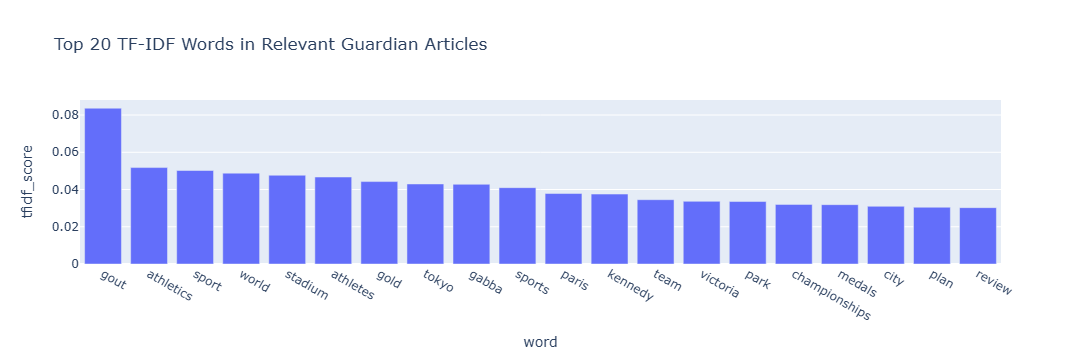

In [55]:
fig = px.bar(
 tfidf_scores_df.head(20),
 x="word",
 y="tfidf_score",
 title="Top 20 TF-IDF Words in Relevant Guardian Articles"
)

fig.show()

## Interpretation:

The TF-IDF results highlight terms that are more distinctive across the filtered Guardian article collection. Terms such as gout, athletics, stadium, athletes, gold, gabba, tokyo, paris, kennedy, victoria, park, medals and championships suggest that the media narratives are shaped by athlete performance, Olympic competition, venue planning, and major event identity.

For ASC, these terms are useful because they show that Brisbane 2032 youth fan engagement can be connected to both athlete-centred stories and local Olympic planning stories. Athlete narratives can support role-model based engagement, while venue and city-related narratives can support local identity and anticipation for Brisbane 2032.

The TF-IDF results should still be interpreted cautiously because they reflect the selected Guardian sample and filtering process. They are useful as narrative evidence, not as a complete measure of public opinion.

# Topic Modelling using NMF

TF-IDF identified important words in the filtered Guardian article collection, but it does not automatically group words into broader themes. To extend the semi-structured analysis, topic modelling is used to identify possible media narratives across the articles.

This section uses Non-negative Matrix Factorisation (NMF) to group related words into topics. These topics can help ASC understand the types of public narratives that appear in Guardian coverage related to sport, Brisbane 2032, athletes, and youth engagement.

The topic results are interpreted carefully because topic modelling does not provide final answers by itself. Instead, it provides evidence that can support stakeholder-focused interpretation.

In [56]:
# create NMF topic model
nmf_model = NMF(n_components=5,random_state=42)

# fit NMF model to TF-IDF vector
nmf_topics = nmf_model.fit_transform(tfidf_vector)

# check topic matrix shape
nmf_topics.shape

(69, 5)

In [57]:
# display top words for each topic
for topic_index, topic in enumerate(nmf_model.components_):
 
 print("Topic", topic_index)
 top_word_indexes = topic.argsort()[-10:]
 for index in top_word_indexes:
 print(tfidf_words[index])
 
 print()

Topic 0
100m
run
national
world
200m
championships
sheppard
athletics
kennedy
gout

Topic 1
premier
host
plans
plan
venues
crisafulli
city
victoria
stadium
park

Topic 2
performance
athletes
world
won
team
paris
medal
tokyo
medals
gold

Topic 3
cup
women
rugby
funding
aoc
hancock
rinehart
athletes
sports
sport

Topic 4
school
federal
7bn
coates
infrastructure
plan
stadium
review
rebuild
gabba



## Creating topic labels

The NMF topic keywords are reviewed and translated into simple topic labels. These labels are interpretive and are used to summarise the main narrative suggested by each topic.

The labels are based on the actual words produced by the topic model. They should not be treated as perfect categories because topic modelling depends on the article sample, filtering process, number of topics, and selected stop words.

In [58]:
topic_labels = {
 0: "Emerging athletics talent narrative",
 1: "Brisbane 2032 venue planning narrative",
 2: "Olympic performance and medal narrative",
 3: "Sport funding and governance narrative",
 4: "Gabba and infrastructure planning narrative"
}

The topic labels below are created after reviewing the NMF keyword output. The labels are interpretive and should be treated as narrative summaries rather than exact categories. These labels should be updated if the topic keywords change after rerunning the model.

In [59]:
# add dominant topic to article dataframe
relevant_guardian_df["topic"] = nmf_topics.argmax(axis=1)

# add topic label
relevant_guardian_df["topic_label"] = relevant_guardian_df["topic"].map(topic_labels)

relevant_guardian_df.head()

,title,text,combined_text,topic,topic_label
0,andrew dillon reveals afl’s olympic-sized ambi...,andrew dillon reveals afl’s olympic-sized ambi...,andrew dillon reveals afl’s olympic-sized ambi...,3,Sport funding and governance narrative
2,"gout and kennedy renew rivalry, hull eyes his...","gout and kennedy renew rivalry, hull eyes his...","gout and kennedy renew rivalry, hull eyes his...",0,Emerging athletics talent narrative
3,"gout gout may be bigger than cathy freeman, bu...","gout gout may be bigger than cathy freeman, bu...","gout gout may be bigger than cathy freeman, bu...",0,Emerging athletics talent narrative
4,two australians created a defining olympic mom...,two australians created a defining olympic mom...,two australians created a defining olympic mom...,2,Olympic performance and medal narrative
5,"eight australian athletes to watch, eight year...","eight australian athletes to watch, eight year...","eight australian athletes to watch, eight year...",2,Olympic performance and medal narrative


## Counting articles by topic

The number of articles in each topic is counted to understand which narratives appear most often in the filtered Guardian article collection.

In [60]:
# count articles by topic label
topic_counts_df = relevant_guardian_df.groupby(["topic_label"]).size().reset_index(name="count")

topic_counts_df

,topic_label,count
0,Brisbane 2032 venue planning narrative,10
1,Emerging athletics talent narrative,14
2,Gabba and infrastructure planning narrative,7
3,Olympic performance and medal narrative,19
4,Sport funding and governance narrative,19


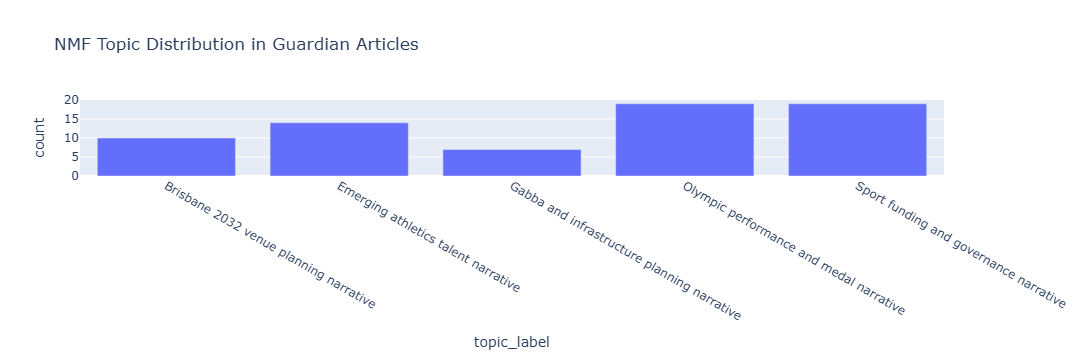

In [61]:
fig = px.bar(
 topic_counts_df,
 x="topic_label",
 y="count",
 title="NMF Topic Distribution in Guardian Articles"
)

fig.show()

The topic distribution shows which NMF narratives appear more often in the filtered Guardian article sample. However, the distribution should not be interpreted as a measure of public opinion. It reflects one media source, one search strategy, the selected article sample, and the chosen number of topics.

For this reason, the topic model is used as supporting narrative evidence rather than as a final decision-making tool. ASC should combine these media insights with participation data and stakeholder consultation before making engagement decisions.

### Interpretation:

The NMF topic model identified five broad media narratives in the filtered Guardian article collection.

The first topic focuses on emerging athletics talent, with terms such as 100m, 200m, championships, athletics, Kennedy, and Gout. This suggests that some media coverage is centred on young or emerging high-performance athletes. For ASC, this type of narrative is useful because athlete stories can provide visible role models for children and adolescents.

The second topic focuses on Brisbane 2032 venue planning, with terms such as host, plans, venues, city, Victoria, stadium, and park. This suggests that part of the media narrative is about where and how the Games will be hosted. For ASC, this can support local identity and anticipation around Brisbane 2032, but it is less directly connected to youth participation unless linked to community access and sport pathways.

The third topic focuses on Olympic performance and medals, with terms such as athletes, team, Paris, Tokyo, medal, medals, and gold. This is relevant because medal and performance narratives can build excitement and national pride. ASC could connect these narratives to youth engagement by showing how current Olympic athletes began through local and youth sport pathways.

The fourth topic focuses on sport funding and governance, with terms such as funding, AOC, Hancock, Rinehart, athletes, sports, and sport. This topic is useful for leadership-level interpretation because youth fan engagement depends not only on communication, but also on investment, athlete support, and sport system capacity.

The fifth topic focuses on Gabba and infrastructure planning, with terms such as school, federal, infrastructure, plan, stadium, review, rebuild, and Gabba. This topic shows that Brisbane 2032 media coverage is partly shaped by infrastructure debate. For ASC, this is important because venue narratives can build local awareness, but they also carry ethical and public trust risks if youth engagement becomes too closely tied to political or infrastructure controversy.

Overall, the NMF results suggest that Guardian media narratives around Brisbane 2032 are shaped by athlete performance, emerging talent, venue planning, sport funding, and infrastructure debate. These themes can support ASC’s youth fan engagement strategy, but they should be used carefully and combined with participation evidence from the structured analysis.

## Ethical Considerations for Semi-Structured Data:

## 1. Media bias in Guardian article data

The Guardian article data provides useful evidence about public media narratives, but it is not a complete view of all sport-related media. It reflects the coverage choices, editorial priorities, and audience focus of one media source.

This means that some sports, athletes, communities, or youth issues may be overrepresented, while others may be underrepresented. Media coverage may also favour elite sport, controversy, major events, or high-profile athletes rather than everyday youth participation.

For ASC, this means the Guardian analysis should be used as one source of narrative evidence, not as a complete measure of public opinion or youth interest.

## 2. Transparency and explainability

The semi-structured analysis uses topic modelling as an extension technique. This method helps identify broad media narratives from Guardian article text, but it does not provide perfect or final answers. Topic modelling depends on the search terms, article collection, number of topics, stop words, and interpretation of keywords. Therefore, the NMF topic labels should be explained as interpretive labels rather than objective facts. For ASC, this means the media narratives should be treated as communication evidence that may support youth fan engagement planning, not as direct proof of what children and young people think about sport or Brisbane 2032.

## Semi-structured analysis summary:

The semi-structured Guardian analysis complements the structured AusPlay analysis by identifying public media narratives connected to Brisbane 2032 and Olympic sport. CountVectorizer identified frequently repeated sport and Olympic terms, while TF-IDF highlighted more distinctive words related to athletes, medals, stadiums, the Gabba, Tokyo, Paris, and major competitions.

NMF topic modelling grouped the article language into five broader narratives: emerging athletics talent, Brisbane 2032 venue planning, Olympic performance and medals, sport funding and governance, and Gabba/infrastructure planning.

For ASC, these findings suggest that youth fan engagement messages should not only focus on participation numbers. They can also draw on athlete role-model stories, Olympic success narratives, local Brisbane 2032 identity, and transparent discussion of sport investment and infrastructure. However, these narratives should be used carefully because media coverage may overrepresent elite sport, stadium debates, and high-profile athletes while underrepresenting everyday youth participation.

# Combined Insights

The structured and semi-structured analyses provide different but complementary evidence for ASC.

The structured AusPlay analysis identifies sports with stronger youth participation patterns. This includes sports with high youth participation, stronger youth concentration, better adolescent continuation, and more balanced participation between males and females.

The semi-structured Guardian article analysis identifies public media narratives connected to sport, Brisbane 2032, athletes, youth, and Olympic engagement. CountVectorizer showed commonly repeated terms, TF-IDF highlighted more distinctive words, and NMF topic modelling grouped article language into broader media themes.

Together, these results help answer the main analytical question:

**How can ASC identify priority Olympic-relevant sports and useful media narratives to build long-term fan support among children and youth before the Brisbane 2032 Olympic Games?**

## Insight 1: Participation strength should not be measured only by size

The structured analysis shows that the largest youth sports are useful starting points for ASC because they already have a strong base of children aged 5–14. These sports may provide immediate opportunities for broad youth engagement campaigns.

However, youth_total alone is not enough. A sport may have many young participants because it is already large overall, but this does not necessarily mean it has the strongest youth engagement potential. The additional variables show that youth concentration, adolescent retention, and gender balance also matter.

For ASC, this means that priority sports should be selected using a balanced participation profile rather than a simple ranked list.

## Insight 2: Clustering supports different engagement strategies

The KMeans clustering grouped sports based on several youth participation characteristics at the same time. This helps ASC think about groups of sports rather than treating every sport in the same way.

Sports in clusters with stronger youth_total may be suitable for broad awareness and fan-building campaigns. Sports with stronger youth_ratio may be useful for school-age engagement because children and young adolescents make up a larger share of their participation base. Sports with stronger adolescent_retention may be important for long-term fan development because young people appear more likely to continue participation into the 12–14 age group.

This suggests that ASC should not use one general youth engagement strategy for all sports. Different clusters may need different communication and participation strategies.

## Insight 3: Media narratives can support participation-based priorities

The semi-structured Guardian analysis identified media narratives around emerging athletics talent, Olympic performance and medals, Brisbane 2032 venue planning, sport funding, and infrastructure debate. These narratives are useful because they show how sport and Brisbane 2032 are being publicly framed.

For ASC, athlete performance and emerging talent narratives are especially useful for youth fan engagement because they can create role models for children and adolescents. For example, stories around athletics, championships, medals, and Olympic teams can help young people connect their own participation with visible athlete pathways.

Venue and infrastructure narratives, such as stadium planning, Victoria Park, and the Gabba, can also support local Brisbane 2032 identity. However, these narratives should be handled carefully because infrastructure debates can become political or controversial. ASC should connect venue narratives to community access, school engagement, and sport pathways rather than only to construction or event planning.

This means media narratives can strengthen participation-based priorities when they are used to make youth sport feel visible, local, aspirational, and connected to Brisbane 2032.

## Insight 4: The strongest ASC opportunities are where participation and narrative overlap

The strongest opportunities for ASC are likely to come from sports that show both:

1. a strong youth participation profile in the structured data, and 
2. useful or visible media narratives in the Guardian article data.

This is important because a sport with high participation but weak public storytelling may need stronger communication support. On the other hand, a sport with strong media visibility but weaker youth participation may need participation-building strategies before it can become a strong youth fan engagement priority.

Therefore, ASC should use the structured data to identify where young people are already participating, and use the semi-structured media analysis to understand how those sports can be communicated through meaningful narratives.

## Practical recommendation for ASC

Based on the combined analysis, ASC should prioritise sports and engagement messages using a three-part approach:

1. **Participation priority** 
 Focus first on sports with strong youth participation profiles, especially those with high youth_total, strong youth_ratio, stronger adolescent_retention, and reasonable gender_balance.

2. **Narrative priority** 
 Connect these sports to media narratives that are likely to appeal to young people and families, such as athlete journeys, Brisbane 2032 preparation, school and community sport, national pride, and Olympic pathways.

3. **Inclusive engagement priority** 
 Avoid relying only on the most popular sports. ASC should also consider whether its strategy supports different genders, age groups, and sports with emerging Olympic relevance.

This approach gives ASC a more balanced and evidence-based way to build youth fan engagement before Brisbane 2032.

## Combined insight summary

The analysis shows that ASC should not make youth engagement decisions using only one form of evidence. Structured participation data helps identify where young people are already involved in sport, while Guardian article data helps identify the narratives that may shape public interest and fan engagement.

By combining these two forms of evidence, ASC can make stronger decisions about which sports to prioritise and how to communicate those sports to children, adolescents, families, schools, and communities before Brisbane 2032.

# Overall ethical reflection:

Ethical considerations are important in this analysis because the scenario focuses on children, youth, sport participation, public media narratives, and stakeholder decision-making. ASC should use the results carefully because the analysis may influence which sports receive attention, support, or engagement resources before Brisbane 2032. The ethical issues are discussed below in relation to the structured AusPlay data, the Guardian article data, and the final recommendations.

## 1. Ethical use of children and youth as a target audience

The scenario focuses on building long-term fan support among children and youth. This creates an important ethical responsibility. Youth engagement should not be treated only as a marketing opportunity. ASC should ensure that engagement strategies support positive outcomes for young people, such as participation, wellbeing, belonging, physical activity, inspiration, and access to role models. Messages should be age-appropriate and should avoid pressuring children or exploiting Olympic enthusiasm for commercial gain.

## 2. Responsible recommendation

The final recommendation should balance participation evidence with fairness and inclusion. ASC should prioritise sports with strong youth engagement potential, but it should also consider whether the strategy supports diverse young people across gender, location, ability, income, and access levels. A responsible approach would use this analysis as a starting point, then combine it with consultation from schools, sporting organisations, athletes, families, and young people themselves.

## Ethical considerations for semi-structured data

The main ethical issue is that data-driven recommendations can influence which sports, groups, and narratives receive attention. If the analysis is used too narrowly, ASC may over-prioritise already popular and visible sports. If used carefully, the analysis can help ASC design a more inclusive and evidence-based youth engagement strategy before Brisbane 2032.

Therefore, the results should be interpreted with caution, transparency, and stakeholder consultation.

# Final Recommendation and Conclusion

This analysis aimed to answer the main analytical question:

**How can the Australian Sports Commission identify Olympic-relevant sports and media narratives that are most suitable for building long-term fan support among children and youth before the Brisbane 2032 Olympic Games?**

The analysis shows that ASC should not rely on one single measure, such as the sports with the highest number of child participants. A stronger decision should combine structured participation evidence with semi-structured media narrative evidence.

## Final recommendation for ASC

ASC should use a combined prioritisation approach for youth fan engagement before Brisbane 2032.

First, ASC should identify sports with strong youth participation profiles. These are sports that have a strong number of participants aged 5–14, a meaningful concentration of young participants, stronger continuation into the 12–14 age group, and reasonable gender balance.

Second, ASC should connect these sports with media narratives that can support long-term youth fan interest. Guardian article analysis can help identify themes around athletes, Olympic pathways, Brisbane 2032, community sport, schools, and national sporting identity.

Third, ASC should avoid focusing only on already popular sports. Sports with lower current participation may still be strategically important if they are Olympic-relevant, inclusive, emerging, or connected to strong athlete and community narratives.

## Practical strategy

Based on the combined analysis, ASC should prioritise sports and engagement messages using a three-part approach:

1. **Participation priority** 
 ASC should first identify sports with strong youth participation profiles, especially sports with high youth_total, strong youth_ratio, stronger adolescent_retention, and reasonable gender_balance. These sports provide the strongest evidence of existing youth engagement.

2. **Narrative priority** 
 ASC should connect priority sports to media narratives identified in the Guardian analysis. Athlete performance, emerging talent, Olympic medals, and Brisbane 2032 local identity are especially useful for youth fan engagement because they make sport feel aspirational and visible.

3. **Responsible engagement priority** 
 ASC should avoid treating media visibility or participation size as the only measure of value. Venue and infrastructure narratives should be used carefully because they may involve political debate. Sports with lower visibility or weaker gender balance should not be ignored; instead, they may require targeted inclusion strategies.

## Conclusion

The structured AusPlay analysis helped identify youth participation patterns across sports. The clustering process extended the analysis by grouping sports with similar participation profiles, making it easier for ASC to think strategically rather than relying on a simple ranking.

The semi-structured Guardian article analysis helped identify media language and possible narratives connected to sport, Brisbane 2032, athletes, and youth engagement. CountVectorizer, TF-IDF, and NMF topic modelling provided evidence about the types of themes appearing in the article data.

Together, the results suggest that ASC should prioritise sports and messages where participation strength and media narrative potential overlap. This gives ASC a more balanced and evidence-based approach for building long-term fan support among children and youth before Brisbane 2032.

However, the recommendations should be used carefully. Data analytics can support decision-making, but it should not replace stakeholder consultation, ethical judgement, or direct engagement with young people, families, schools, athletes, and sporting organisations.